# **PROJECT TITLE**

# Online Retail Sales Analysis (2010-2011)

# **Domain: E-Commerce**

# Objectives

To analyze online retail sales and customer purchasing patterns using Python.

To clean and preprocess the retail transaction data for accurate analysis.

To identify top-selling products, high-revenue countries, and sales trends.

To generate meaningful business insights to support better decision-making.

New Column Added in Online Retail Dataset

**• TotalAmount:**

  → Created to calculate the total transaction value for each purchase

  → Calculated by multiplying Quantity × UnitPrice

  → Helps analyze sales revenue and customer spending

# **Dataset Information**

Dataset Name: Online Retail Dataset

Source: UCI Machine Learning Repository

Domain: E-Commerce / Retail

Records: 541,909 transactions

Features: 8 columns

Time Period: December 2010 – December 2011

Main Information: Invoice details, products, quantity, price, customer ID, date, and country.

# **Stage 1: Problem Definition**

**1. Import Libraries & Load Dataset**

In [ ]:

import pandas as pd                   # data manipulation and analysis
import numpy as np                    # numerical operations
import matplotlib.pyplot as plt       # Data visualizations
import seaborn as sns                 # statistical / styled visualizations built on top of matplotlib
import warnings
warnings.filterwarnings('ignore')

In [ ]:
!git clone https://github.com/hemadurai031/online-retail-analysis.git

Cloning into 'online-retail-analysis'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.


In [ ]:
%cd online-retail-analysis

/content/online-retail-analysis/online-retail-analysis


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Online Retail.xlsx to Online Retail.xlsx


In [ ]:
df = pd.read_excel("/content/online-retail-analysis/Online Retail.xlsx")
print("Original Shape:", df.shape)

Original Shape: (541909, 8)


In [ ]:
df.shape

(541909, 8)

In [ ]:
#first 10 rows
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom


In [ ]:
#last 10 rows
df.tail(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541899,581587,22726,ALARM CLOCK BAKELIKE GREEN,4,2011-12-09 12:50:00,3.75,12680.0,France
541900,581587,22730,ALARM CLOCK BAKELIKE IVORY,4,2011-12-09 12:50:00,3.75,12680.0,France
541901,581587,22367,CHILDRENS APRON SPACEBOY DESIGN,8,2011-12-09 12:50:00,1.95,12680.0,France
541902,581587,22629,SPACEBOY LUNCH BOX,12,2011-12-09 12:50:00,1.95,12680.0,France
541903,581587,23256,CHILDRENS CUTLERY SPACEBOY,4,2011-12-09 12:50:00,4.15,12680.0,France
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [ ]:
#Online retail shop details
print(f"Online Retail Shop details: \n {df.info()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB
Online Retail Shop details: 
 None


In [ ]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [ ]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [ ]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [ ]:
df.duplicated().sum()

np.int64(5268)

In [ ]:
df[df.duplicated(keep=False)]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
...,...,...,...,...,...,...,...,...
541675,581538,22068,BLACK PIRATE TREASURE CHEST,1,2011-12-09 11:34:00,0.39,14446.0,United Kingdom
541689,581538,23318,BOX OF 6 MINI VINTAGE CRACKERS,1,2011-12-09 11:34:00,2.49,14446.0,United Kingdom
541692,581538,22992,REVOLVER WOODEN RULER,1,2011-12-09 11:34:00,1.95,14446.0,United Kingdom
541699,581538,22694,WICKER STAR,1,2011-12-09 11:34:00,2.10,14446.0,United Kingdom


In [ ]:
#clean text columns
print("Duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates().copy()

print("Shape after removing duplicates:", df.shape)

Duplicate rows: 5268
Shape after removing duplicates: (536641, 8)


In [ ]:
#Clean text columns
df['Description'] = df['Description'].fillna('Unknown')

df['Description'] = df['Description'].str.strip().str.upper()

df['Country'] = df['Country'].str.strip().str.title()

In [ ]:
#convert data types
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['CustomerID'] = df['CustomerID'].astype('Int64')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 536641 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    536641 non-null  object        
 1   StockCode    536641 non-null  object        
 2   Description  536640 non-null  object        
 3   Quantity     536641 non-null  int64         
 4   InvoiceDate  536641 non-null  datetime64[ns]
 5   UnitPrice    536641 non-null  float64       
 6   CustomerID   401604 non-null  Int64         
 7   Country      536641 non-null  object        
dtypes: Int64(1), datetime64[ns](1), float64(1), int64(1), object(4)
memory usage: 37.4+ MB


In [ ]:
#lets smaple for i use invoice no how many dupliactes are invoice
df['InvoiceNo'].duplicated().sum()


np.int64(510741)

In [ ]:
df['InvoiceNo'].nunique()

25900

# **Stage 2 - Data cleaning**

In [ ]:
# Missing values count
print("--- Missing Values ---")
print(df.isnull().sum())

--- Missing Values ---
InvoiceNo           0
StockCode           0
Description         1
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135037
Country             0
dtype: int64


In [ ]:
# Duplicate rows check
print("--- Duplicate Rows ---")
print(f"Total duplicates: {df.duplicated().sum()}")
print("Shape after removing duplicates:", df.shape)

--- Duplicate Rows ---
Total duplicates: 0
Shape after removing duplicates: (536641, 8)


In [ ]:
# Drop duplicates
df = df.drop_duplicates()
print(f"Shape after removing duplicates: {df.shape}")

Shape after removing duplicates: (536641, 8)


In [ ]:
# Handle missing CustomerID - drop rows (since customer-level analysis needs valid ID)
df = df.dropna(subset=['CustomerID'])

# Handle missing Description - fill with 'Unknown'
df['Description'] = df['Description'].fillna('Unknown')

print(f"Shape after handling missing values: {df.shape}")
print(df.isnull().sum())

Shape after handling missing values: (401604, 8)
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


In [ ]:
df['is_cancelled'] = df['InvoiceNo'].astype(str).str.startswith('C')

In [ ]:
df = df[df['UnitPrice'] > 0]

In [ ]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['CustomerID'] = df['CustomerID'].astype('Int64')  # nullable int

In [ ]:
df['Description'] = df['Description'].str.strip().str.upper()
df['Country'] = df['Country'].str.strip().str.title()

In [ ]:
df['year'] = df['InvoiceDate'].dt.year
df['month'] = df['InvoiceDate'].dt.month
df['total_amount'] = df['Quantity'] * df['UnitPrice']

In [ ]:
print(df.isnull().sum())
print(df.shape)

InvoiceNo       0
StockCode       0
Description     0
Quantity        0
InvoiceDate     0
UnitPrice       0
CustomerID      0
Country         0
is_cancelled    0
year            0
month           0
total_amount    0
dtype: int64
(401564, 12)


In [ ]:
# Create TotalAmount column
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

# Check the new column
df[['Quantity', 'UnitPrice', 'TotalAmount']].head()

,Quantity,UnitPrice,TotalAmount
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


stastical analysis

In [ ]:
# STATISTICAL ANALYSIS - Numerical Columns

print("----- Measure of Central Tendency -----")

print(f"Quantity Mean   : {df['Quantity'].mean():.2f}")
print(f"Quantity Median : {df['Quantity'].median():.2f}")

print(f"UnitPrice Mean   : {df['UnitPrice'].mean():.2f}")
print(f"UnitPrice Median : {df['UnitPrice'].median():.2f}")

print(f"TotalAmount Mean   : {df['total_amount'].mean():.2f}")
print(f"TotalAmount Median : {df['total_amount'].median():.2f}")

----- Measure of Central Tendency -----
Quantity Mean   : 12.15
Quantity Median : 5.00
UnitPrice Mean   : 3.47
UnitPrice Median : 1.95
TotalAmount Mean   : 20.62
TotalAmount Median : 11.70


In [ ]:
print("----- Variance & Standard Deviation -----")

print("\nQuantity")
print(f"Std      : {df['Quantity'].std():.2f}")
print(f"Variance : {df['Quantity'].var():.2f}")
print(f"Min      : {df['Quantity'].min():.2f}")
print(f"Max      : {df['Quantity'].max():.2f}")

print("\nUnitPrice")
print(f"Std      : {df['UnitPrice'].std():.2f}")
print(f"Variance : {df['UnitPrice'].var():.2f}")
print(f"Min      : {df['UnitPrice'].min():.2f}")
print(f"Max      : {df['UnitPrice'].max():.2f}")

print("\nTotalAmount")
print(f"Std      : {df['total_amount'].std():.2f}")
print(f"Variance : {df['total_amount'].var():.2f}")
print(f"Min      : {df['total_amount'].min():.2f}")
print(f"Max      : {df['total_amount'].max():.2f}")

----- Variance & Standard Deviation -----

Quantity
Std      : 249.51
Variance : 62256.56
Min      : -80995.00
Max      : 80995.00

UnitPrice
Std      : 69.77
Variance : 4867.50
Min      : 0.00
Max      : 38970.00

TotalAmount
Std      : 430.37
Variance : 185221.44
Min      : -168469.60
Max      : 168469.60


In [ ]:
print("----- Skewness & Kurtosis -----")

for column in ['Quantity', 'UnitPrice', 'total_amount']:
    print(f"\n{column}")
    print(f"Skewness : {df[column].skew():.2f}")
    print(f"Kurtosis : {df[column].kurt():.2f}")

----- Skewness & Kurtosis -----

Quantity
Skewness : -0.13
Kurtosis : 94289.53

UnitPrice
Skewness : 449.29
Kurtosis : 243736.78

total_amount
Skewness : -0.06
Kurtosis : 122433.13


In [ ]:
print("----- Year-wise Sales Statistics -----")

df.groupby(df['InvoiceDate'].dt.year)['total_amount'].agg(
    ['count', 'mean', 'median', 'std']
).round(2)

----- Year-wise Sales Statistics -----


,count,mean,median,std
InvoiceDate,,,,
2010,26351,20.96,10.5,77.85
2011,375213,20.59,11.7,444.75


# **Stage 3 – Data Visualization**

# Monthly Sales Trend:

The line chart shows how total sales change month by month. It helps identify periods of high and low sales and provides a clear view of the overall sales trend and seasonal patterns.

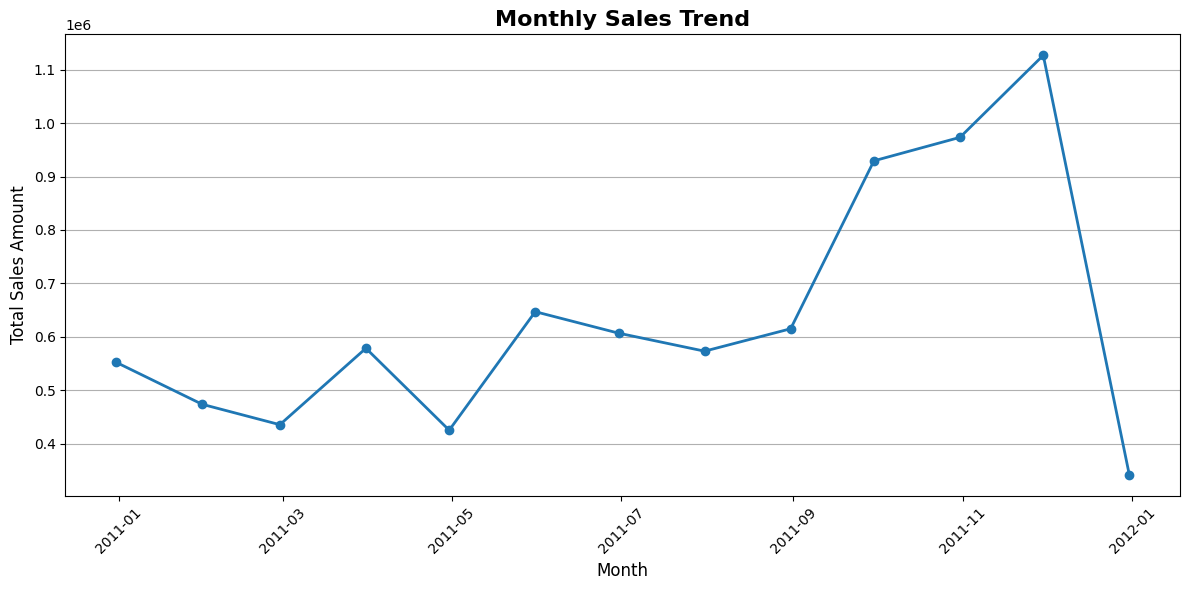

In [ ]:
# Visualization 1: Monthly Sales Trend
# Shows the total sales generated in each month
# Helps identify periods of increasing or decreasing sales
# Makes it easier to observe seasonal sales patterns over time

monthly_sales = (
    df
    .set_index('InvoiceDate')
    .resample('M')['total_amount']
    .sum()
)

plt.figure(figsize=(12, 6))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', linewidth=2)

plt.title('Monthly Sales Trend', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Sales Amount', fontsize=12)
plt.grid(True, axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Top 10 Countries by Total Sales:

The horizontal bar chart compares sales revenue across the top 10 countries. It helps identify the strongest geographical markets and understand where the business generates the most revenue.

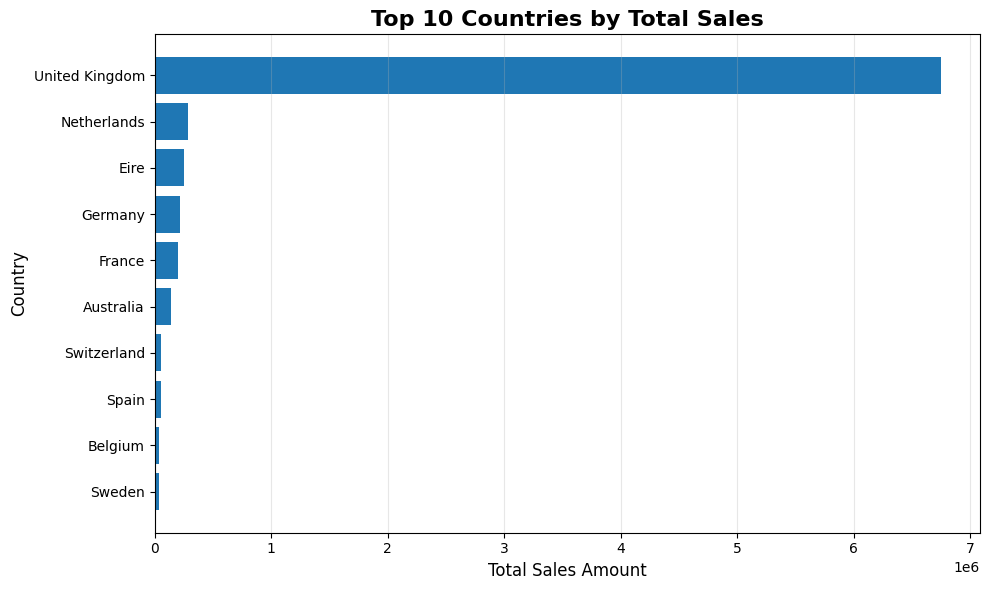

In [ ]:
# Visualization 2: Top 10 Countries by Total Sales
# Compares the total sales generated by the top 10 countries
# Helps identify the countries contributing the highest sales revenue
# Supports understanding of the major geographical markets

country_sales = (
    df.groupby('Country')['total_amount']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

plt.figure(figsize=(10, 6))
plt.barh(country_sales.index, country_sales.values)

plt.title('Top 10 Countries by Total Sales', fontsize=16, fontweight='bold')
plt.xlabel('Total Sales Amount', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Quantity vs Total Sales Amount:

The scatter plot illustrates the relationship between the quantity purchased and the total sales amount. It helps understand purchasing patterns and identify transactions with unusually high quantities or sales values.

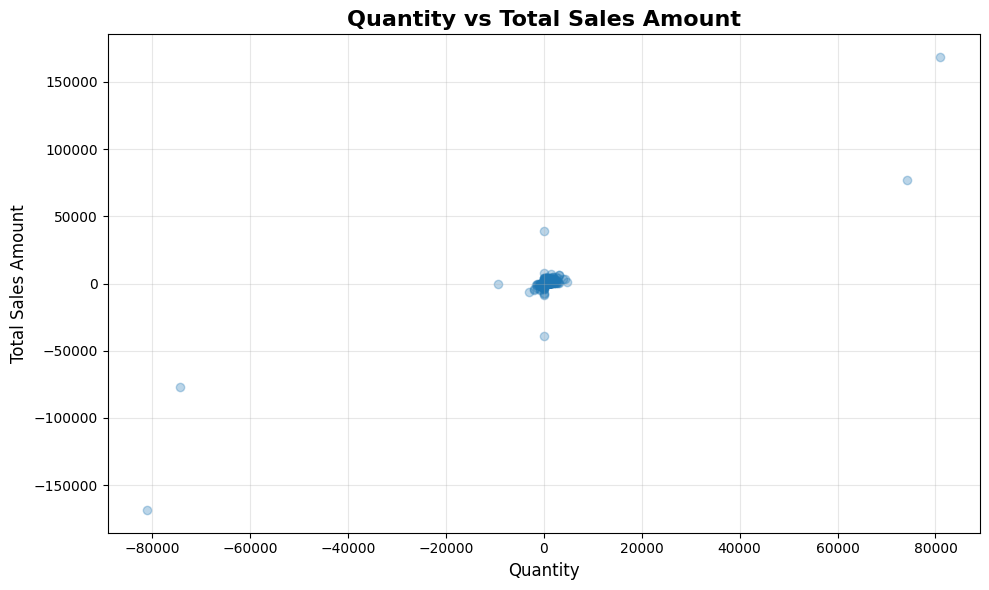

In [ ]:
# Visualization 3: Quantity vs Total Sales Amount
# Shows the relationship between the quantity purchased and total sales amount
# Helps understand how purchase quantity affects the overall transaction value
# Also helps identify unusual transactions and extreme values

plt.figure(figsize=(10, 6))

plt.scatter(
    df['Quantity'],
    df['total_amount'],
    alpha=0.3
)

plt.title('Quantity vs Total Sales Amount', fontsize=16, fontweight='bold')
plt.xlabel('Quantity', fontsize=12)
plt.ylabel('Total Sales Amount', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Quantity vs Unit Price:

The scatter plot shows the relationship between the quantity purchased and the unit price. It helps understand whether purchase quantity varies with product price and also highlights unusual transactions or outliers.

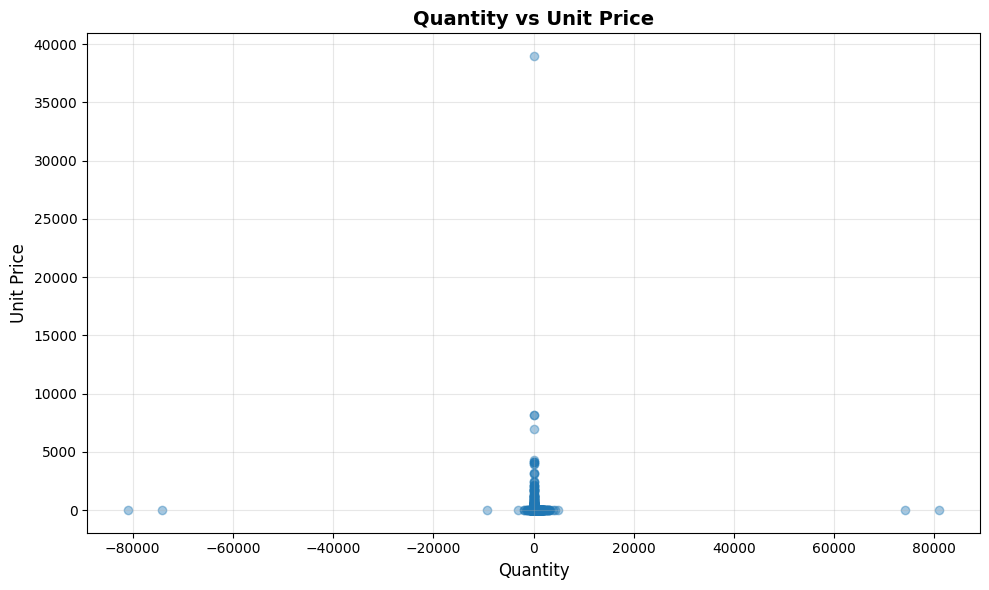

In [ ]:
# Visualization 4: Scatter Plot
# Quantity vs Unit Price
# Shows the relationship between quantity purchased and unit price
# Helps identify patterns between product quantity and pricing
# Also helps detect unusual values or outliers in the transactions

plt.figure(figsize=(10, 6))

plt.scatter(
    df["Quantity"],
    df["UnitPrice"],
    alpha=0.4
)

plt.title("Quantity vs Unit Price", fontsize=14, fontweight="bold")
plt.xlabel("Quantity", fontsize=12)
plt.ylabel("Unit Price", fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Top 5 Countries by Sales Contribution:

The pie chart shows the percentage contribution of the top five countries to total sales. It helps identify which countries contribute the largest share of sales revenue.

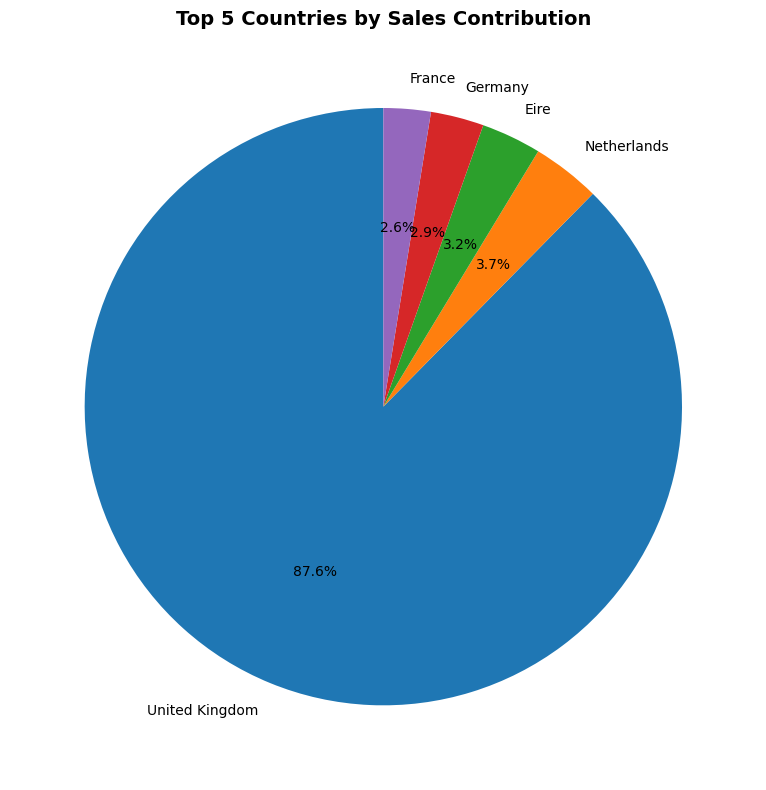

In [ ]:
# Visualization 5: Pie Chart
# Top 5 Countries by Total Sales
# Shows the contribution of the top 5 countries to overall sales
# Helps compare the sales share of each country
# Highlights the countries generating the highest sales revenue

country_sales = (
    df.groupby("Country")["total_amount"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

plt.figure(figsize=(8, 8))

plt.pie(
    country_sales.values,
    labels=country_sales.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Top 5 Countries by Sales Contribution",
          fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

# Year-wise Monthly Sales:

The heatmap represents monthly sales across different years. Darker and lighter shades help compare sales performance between months and identify seasonal patterns and periods of high or low sales.

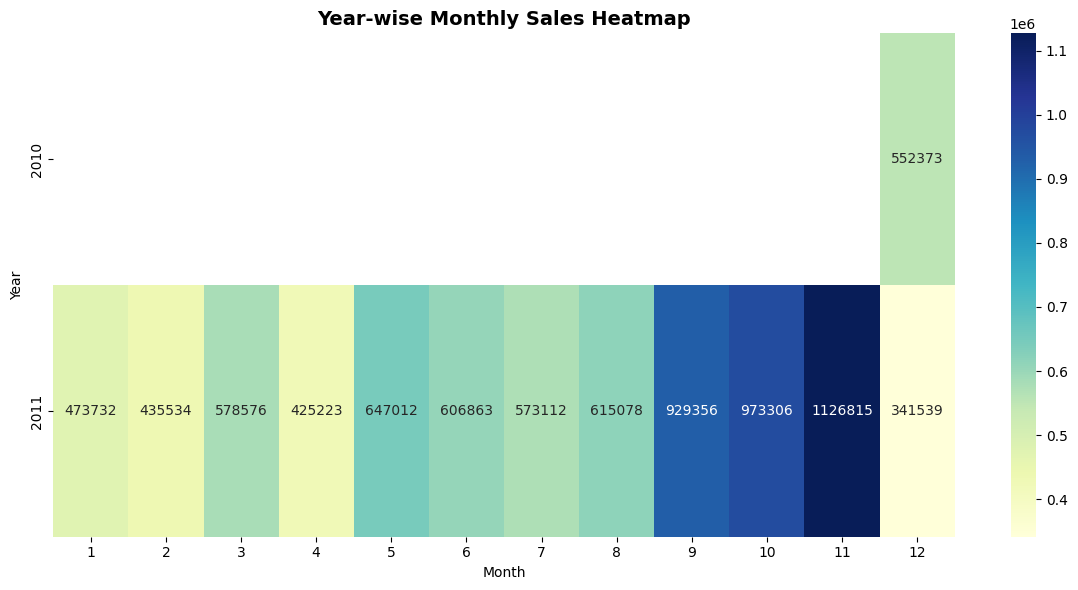

In [ ]:
# Visualization 6: Heatmap
# Year-wise Monthly Sales
# Shows the sales performance for each month across different years
# Helps identify months with higher and lower sales activity
# Makes it easier to observe seasonal sales patterns and variations

df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month

monthly_sales = df.pivot_table(
    index="Year",
    columns="Month",
    values="total_amount",
    aggfunc="sum"
)

plt.figure(figsize=(12, 6))

sns.heatmap(
    monthly_sales,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Year-wise Monthly Sales Heatmap",
          fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Year")

plt.tight_layout()
plt.show()

# Distribution of Total Sales Amount:

The box plot shows the distribution and variation of total sales amounts. It helps identify the median sales value and detect extreme transactions that may appear as outliers.

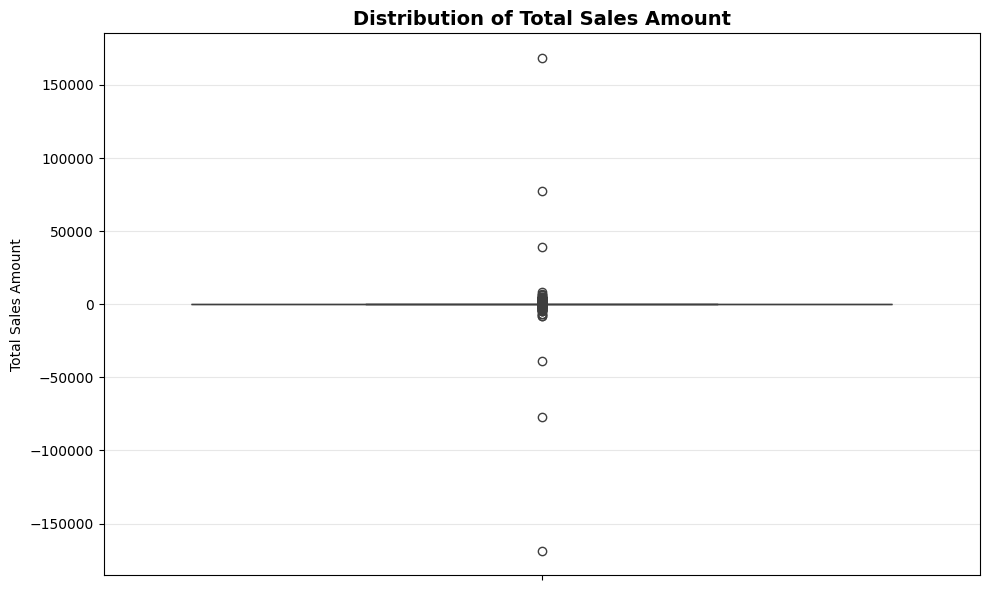

In [ ]:
# Visualization 7: Box Plot
# Distribution of Total Sales Amount
# Shows the median and spread of sales amounts
# Helps identify the variation in transaction values
# Highlights unusually high or low sales transactions as outliers

plt.figure(figsize=(10, 6))

sns.boxplot(
    y=df["total_amount"].dropna()
)

plt.title("Distribution of Total Sales Amount",
          fontsize=14, fontweight="bold")
plt.ylabel("Total Sales Amount")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Distribution of Quantity:

The histogram shows that most transactions involve relatively small quantities, while a few transactions have unusually high quantities. This indicates a right-skewed distribution with some extreme values. **bold text**

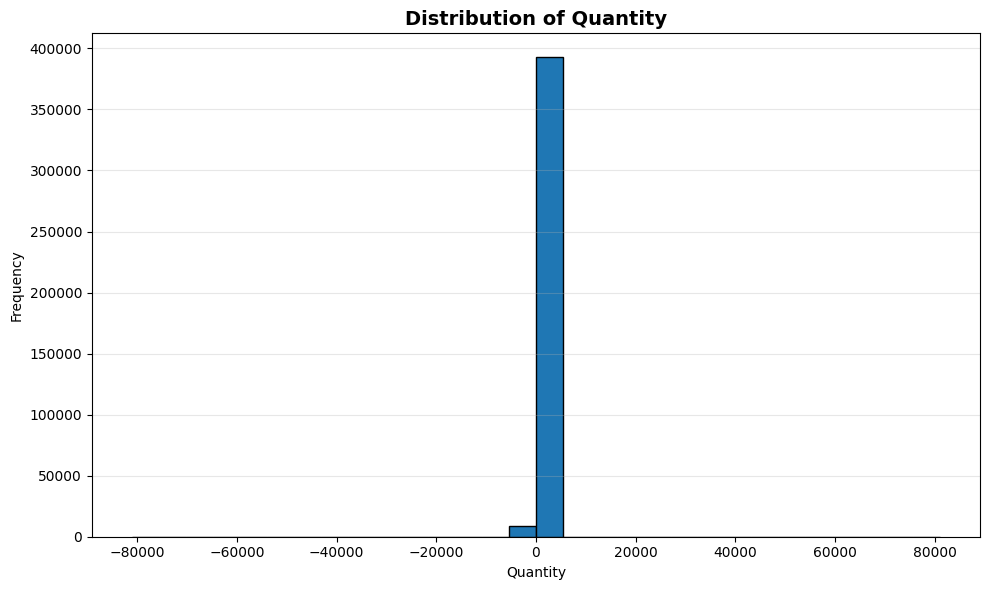

In [ ]:
# Visualization 8: Histogram
# Distribution of Quantity
# Shows how frequently different quantity ranges occur
# Helps identify the most common purchase quantities and extreme values

plt.figure(figsize=(10, 6))

plt.hist(
    df["Quantity"].dropna(),
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Quantity",
          fontsize=14, fontweight="bold")
plt.xlabel("Quantity")
plt.ylabel("Frequency")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Monthly Sales Trend:
**The area chart shows the month-wise movement of total sales over time. It helps identify periods of higher and lower sales and highlights overall sales trends and seasonal variations.**

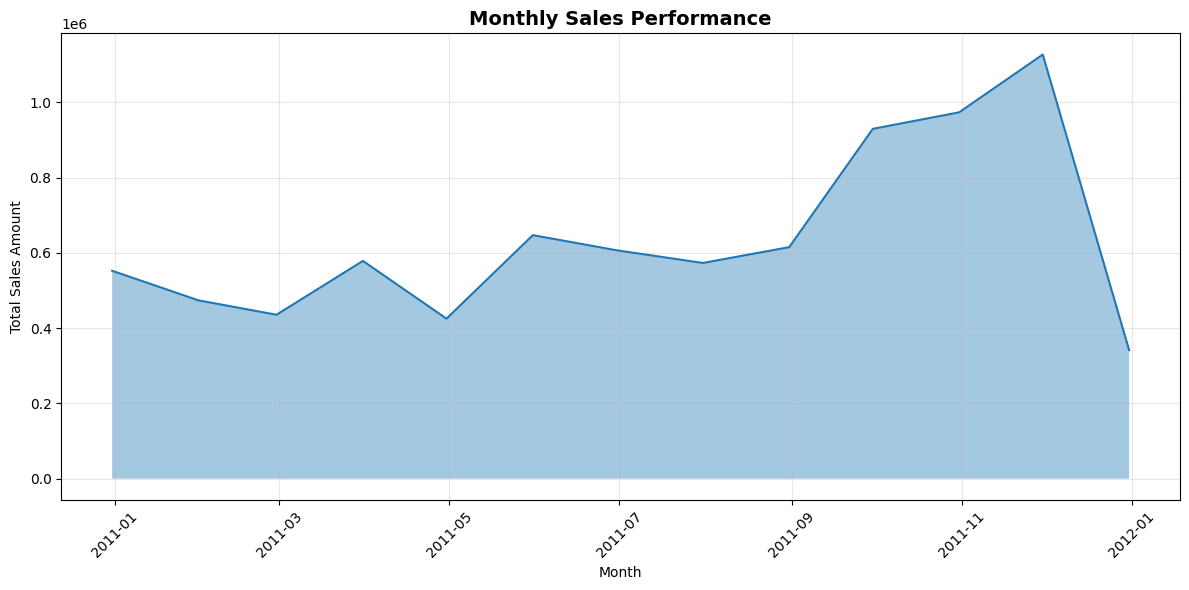

In [ ]:
# Visualization 9: Area Chart
# Monthly Sales Trend
# Shows how total sales change month by month
# Helps identify sales growth, decline, and seasonal patterns
# The filled area highlights the overall sales performance over time
monthly_sales = (
    df.set_index("InvoiceDate")
    .resample("M")["total_amount"]
    .sum()
)

plt.figure(figsize=(12, 6))

plt.fill_between(
    monthly_sales.index,
    monthly_sales.values,
    alpha=0.4
)

plt.plot(
    monthly_sales.index,
    monthly_sales.values
)

plt.title("Monthly Sales Performance",
          fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Total Sales Amount")

plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# **Stage 4 - Types of Analysis**

In [ ]:
# Descriptive Analysis
# What happened? — Summary of Online Retail Sales

print("=" * 50)
print("DESCRIPTIVE ANALYSIS SUMMARY")
print("=" * 50)

print(f"\nTotal Transactions : {df.shape[0]}")
print(f"Total Columns      : {df.shape[1]}")
print(f"Total Customers    : {df['CustomerID'].nunique()}")
print(f"Countries Covered  : {df['Country'].nunique()}")
print(f"Products Sold      : {df['Description'].nunique()}")
print(f"Total Quantity Sold: {df['Quantity'].sum():,.0f}")
print(f"Total Sales Amount : {df['total_amount'].sum():,.2f}")

DESCRIPTIVE ANALYSIS SUMMARY

Total Transactions : 401564
Total Columns      : 15
Total Customers    : 4371
Countries Covered  : 37
Products Sold      : 3885
Total Quantity Sold: 4,878,967
Total Sales Amount : 8,278,519.42


In [ ]:
# Diagnostic Analysis
# Why did it happen? — Root cause exploration

print("\n--- Top 5 Countries by Sales ---")

country_sales = (
    df.groupby("Country")["total_amount"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

print(country_sales)

print("\n--- Top 10 Products by Sales ---")

product_sales = (
    df.groupby("Description")["total_amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(product_sales)

print("\n--- Monthly Sales Analysis ---")

monthly_sales = (
    df.set_index("InvoiceDate")["total_amount"]
    .resample("M")
    .sum()
)

print(monthly_sales)


--- Top 5 Countries by Sales ---
Country
United Kingdom    6747156.154
Netherlands        284661.540
Eire               250001.780
Germany            221509.470
France             196626.050
Name: total_amount, dtype: float64

--- Top 10 Products by Sales ---
Description
REGENCY CAKESTAND 3 TIER              132567.70
WHITE HANGING HEART T-LIGHT HOLDER     93767.80
JUMBO BAG RED RETROSPOT                83056.52
PARTY BUNTING                          67628.43
POSTAGE                                66710.24
ASSORTED COLOUR BIRD ORNAMENT          56331.91
RABBIT NIGHT LIGHT                     51042.84
CHILLI LIGHTS                          45915.41
PAPER CHAIN KIT 50'S CHRISTMAS         41423.78
PICNIC BASKET WICKER 60 PIECES         39619.50
Name: total_amount, dtype: float64

--- Monthly Sales Analysis ---
InvoiceDate
2010-12-31     552372.860
2011-01-31     473731.900
2011-02-28     435534.070
2011-03-31     578576.210
2011-04-30     425222.671
2011-05-31     647011.670
2011-06-30  

In [ ]:
# Predictive Analysis
# What may happen? — Simple monthly sales trend prediction

import numpy as np

monthly_sales = (
    df.set_index("InvoiceDate")["total_amount"]
    .resample("M")
    .sum()
)

# Convert months into numerical values
x = np.arange(len(monthly_sales))
y = monthly_sales.values

# Linear trend calculation
z = np.polyfit(x, y, 1)
p = np.poly1d(z)

# Predict next 3 months
future_x = np.arange(len(monthly_sales), len(monthly_sales) + 3)
future_predictions = p(future_x)

print("--- Future Sales Prediction ---")

for i, value in enumerate(future_predictions, start=1):
    print(f"Next Month {i} Predicted Sales : {value:,.2f}")

--- Future Sales Prediction ---
Next Month 1 Predicted Sales : 848,719.04
Next Month 2 Predicted Sales : 878,991.87
Next Month 3 Predicted Sales : 909,264.71
